# 선형회귀

### (1) sklearn으로 선형 회귀 구현

In [145]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np

In [146]:
X = np.array([10, 20, 30, 40, 50, 60, 70, 80]).reshape(-1, 1)
y = np.array([25, 45, 55, 70, 85, 95, 110, 120])

In [147]:
X.shape

(8, 1)

In [148]:
train_test_split(X, y, random_state=42)

[array([[10],
        [80],
        [30],
        [50],
        [40],
        [70]]),
 array([[20],
        [60]]),
 array([ 25, 120,  55,  85,  70, 110]),
 array([45, 95])]

In [149]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42
)

In [150]:
model=LinearRegression()
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [151]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


선형 회귀는 최적의 선을 찾는 과정
- w = 기울기 (coef)
- b = 절편 (intercept)

In [152]:
model.coef_

array([1.365])

In [153]:
model.intercept_

np.float64(13.800000000000011)

In [154]:
print(f'y={model.coef_[0]:.2f}x + {model.intercept_:.2f}')

y=1.36x + 13.80


In [155]:
model.score(X_test, y_test)

0.9874400000000001

In [156]:
from sklearn.metrics import r2_score, root_mean_squared_error

In [157]:
y_pred = model.predict(X_test)

In [158]:
r2_score(y_test, y_pred)

0.9874400000000001

### (2) statsmodels로 선형 회귀 구현
- 절편 따로 정의해야 함

In [159]:
!pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [160]:
import statsmodels.api as sm
X_train_sm = sm.add_constant(X_train)
X_train_sm

array([[ 1., 10.],
       [ 1., 80.],
       [ 1., 30.],
       [ 1., 50.],
       [ 1., 40.],
       [ 1., 70.]])

In [161]:
model_sm = sm.OLS(y_train, X_train_sm).fit()

> R-squared와 Adj. R-squared 차이가 크면 → 불필요한 특성이 포함되어 있을 가능성

In [162]:
print(f"R²:     {model_sm.rsquared:.4f}")
print(f"Adj R²: {model_sm.rsquared_adj:.4f}")

R²:     0.9957
Adj R²: 0.9946


In [163]:
model_sm.summary()

C:\Users\kmfm1\AppData\Roaming\Python\Python311\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     928.7
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           6.91e-06
Time:                        16:12:56   Log-Likelihood:                -12.998
No. Observations:                   6   AIC:                             30.00
Df Residuals:                       4   BIC:                             29.58
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.8000      2.342      5.893      0.004       7.298      20.302
x1             1.3650      0.045     30.475      0.000       1.241       1.489
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   0.781
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.483
Skew:                          -0.206   Prob(JB):                        0.785
Kurtosis:                       1.673   Cond. No.                         116.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## (3) 다중 선형 회귀

### (1) sklearn으로 구현 

In [164]:
from sklearn.datasets import fetch_california_housing

In [165]:
housing = fetch_california_housing()

In [166]:
import pandas as pd

In [167]:
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.DataFrame(housing.target, columns=housing.target_names)

In [168]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [169]:
y.head()

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [170]:
X_train, X_test, y_train, y_test = train_test_split(
                                                    X,y,
                                                    test_size=0.2,
                                                    random_state=42
                                                    )

In [171]:
X_train.shape

(16512, 8)

In [172]:
X_test.shape

(4128, 8)

In [173]:
model = LinearRegression()
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [174]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [175]:
for name, coef in zip(housing.feature_names, model.coef_[0]):
    print(f'{name} : {coef:.2f}')

MedInc : 0.45
HouseAge : 0.01
AveRooms : -0.12
AveBedrms : 0.78
Population : -0.00
AveOccup : -0.00
Latitude : -0.42
Longitude : -0.43


In [176]:
model.coef_

array([[ 4.48674910e-01,  9.72425752e-03, -1.23323343e-01,
         7.83144907e-01, -2.02962058e-06, -3.52631849e-03,
        -4.19792487e-01, -4.33708065e-01]])

### (2) statsmodels로 구현

In [177]:
X_train_sm = sm.add_constant(X_train)

model_sm = sm.OLS(y_train, X_train_sm).fit()
model_sm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            MedHouseVal   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:                  0.612
Method:                 Least Squares   F-statistic:                     3261.
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:12:56   Log-Likelihood:                -17998.
No. Observations:               16512   AIC:                         3.601e+04
Df Residuals:                   16503   BIC:                         3.608e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -37.0233      0.728    -50.835      0.000     -38.451     -35.596
MedInc         0.4487      0.005     95.697      0.000       0.439       0.458
HouseAge       0.0097      0.000     19.665      0.000       0.009       0.011
AveRooms      -0.1233      0.007    -18.677      0.000      -0.136      -0.110
AveBedrms      0.7831      0.033     23.556      0.000       0.718       0.848
Population  -2.03e-06   5.25e-06     -0.387      0.699   -1.23e-05    8.26e-06
AveOccup      -0.0035      0.000     -7.253      0.000      -0.004      -0.003
Latitude      -0.4198      0.008    -52.767      0.000      -0.435      -0.404
Longitude     -0.4337      0.008    -52.117      0.000      -0.450      -0.417
==============================================================================
Omnibus:                     3333.187   Durbin-Watson:                   1.962
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             9371.466
Skew:                           1.071   Prob(JB):                         0.00
Kurtosis:                       6.006   Cond. No.                     2.38e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.38e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [178]:
model_base = LinearRegression().fit(X_train, y_train)

In [179]:
np.random.seed(42)
noise = np.random.randn(X_train.shape[0], 5)
X_train_noisy = np.hstack([X_train, noise])

model_noisy = LinearRegression().fit(X_train_noisy, y_train)

In [180]:
print(f"원래 8개 특성 → Train R²: {model_base.score(X_train, y_train):.4f}")
print(f"랜덤 5개 추가 → Train R²: {model_noisy.score(X_train_noisy, y_train):.4f}")

원래 8개 특성 → Train R²: 0.6126
랜덤 5개 추가 → Train R²: 0.6127


In [181]:
noise

array([[ 0.49671415, -0.1382643 ,  0.64768854,  1.52302986, -0.23415337],
       [-0.23413696,  1.57921282,  0.76743473, -0.46947439,  0.54256004],
       [-0.46341769, -0.46572975,  0.24196227, -1.91328024, -1.72491783],
       ...,
       [-1.24721081, -0.40922731, -0.86557668,  0.34475   ,  0.43114449],
       [-0.60126506, -1.63985642,  2.81222111,  0.32255953,  0.32024626],
       [-1.87438969,  0.72396728,  1.06368244,  0.33821823,  0.13405368]],
      shape=(16512, 5))

In [182]:
model.score(X_train, y_train)

0.6125511913966952

In [183]:
model_noisy.score(X_train_noisy, y_train)

0.6126868487580268

## (4) 다중 선형회귀에서의 주의사항

### (1) 다중공선성 : 독립 변수(x)간에 강한 상관관계

In [187]:
import seaborn as sns

In [186]:
X[['AveRooms','AveBedrms']].corr()
# 현재 X 끼리의 높은 상관관계 발생

,AveRooms,AveBedrms
AveRooms,1.000000,0.847621
AveBedrms,0.847621,1.000000


<Axes: >

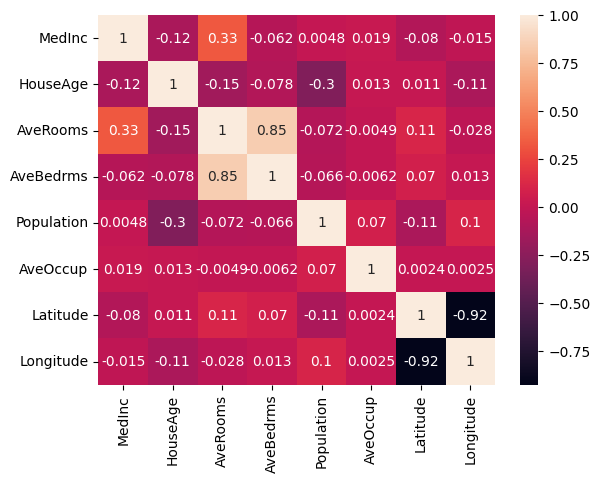

In [190]:
sns.heatmap(X.corr(), annot=True)

In [192]:
X_train_sm

,const,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,1.0,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,1.0,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,1.0,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.0,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,1.0,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80
...,...,...,...,...,...,...,...,...,...
11284,1.0,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,1.0,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,1.0,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,1.0,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [194]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [197]:
variance_inflation_factor(X_train_sm.values, 1)

np.float64(2.5398149470924802)

In [198]:
X_train_sm.head()

,const,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,1.0,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,1.0,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,1.0,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.0,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,1.0,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80


In [202]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train_sm.values, i+1)
    for i in range(X.shape[1])
]
vif_data.sort_values(by='VIF', ascending=False)

,Feature,VIF
6,Latitude,9.206134
7,Longitude,8.875984
2,AveRooms,7.917240
3,AveBedrms,6.609200
0,MedInc,2.539815
1,HouseAge,1.237337
4,Population,1.134824
5,AveOccup,1.009733
